# From rain to crops to prices: satellite crop greenness in Uganda
**Greenness:** MODIS vegetation indices (NDVI, EVI) at 250 m, monthly, averaged over cropland and over pasture (grassland and shrubland) in each region. Main series from the Terra satellite (February 2000 – August 2026); the Aqua satellite (July 2002 onwards) is used as an independent check. Exported with `scripts/gee/uganda_cropland_ndvi_gee.js`.
**Rainfall, prices:** as in notebook 02.

**Questions**
1. Does crop greenness respond to rainfall, and how quickly?
2. Does it pick up Uganda's known droughts?
3. Does weaker greenness lead to higher food prices, and does it predict prices better than rainfall?
4. What do crops and pasture in Karamoja show about the 2022 food crisis?

**Why greenness.** Rainfall says how much water arrived; greenness says how crops actually grew. If the rainfall-to-price link found in notebook 02 really runs through harvests, greenness should sit in the middle of that chain.

Each finding is written up in a markdown cell directly after the code and output that produced it.

## Setup and data checks

In [1]:
import sys, warnings
sys.path.insert(0, '../scripts')
warnings.filterwarnings('ignore', category=FutureWarning)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# House style, shared with the rainfall project
WET, DRY, ACCENT, INK, MUTED, GRID = '#2b6c9e', '#c4572e', '#16825a', '#132019', '#7a877f', '#e6e9e4'
plt.rcParams.update({
    'figure.dpi': 110, 'font.size': 10, 'axes.titlesize': 12, 'axes.titleweight': 'bold',
    'axes.titlelocation': 'left', 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': '#c9cfc8', 'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8,
    'axes.axisbelow': True, 'xtick.color': MUTED, 'ytick.color': MUTED, 'axes.labelcolor': MUTED,
    'legend.frameon': False,
})
pd.set_option('display.width', 200)

import statsmodels.api as sm
import statsmodels.formula.api as smf
import prices as P
from prices import load_vegetation, season_greenness, monthly_anomaly, seasonal_rain_z, season_panel, fit
rng = np.random.default_rng(42)
MON = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
REGIONS = ['Uganda (national)', 'Karamoja', 'Northern', 'Eastern', 'Central', 'Western', 'Lake Victoria basin']

terra, aqua = load_vegetation('terra'), load_vegetation('aqua')
print('Terra:', terra['date'].min(), '–', terra['date'].max(), '| rows', len(terra), '| missing NDVI', int(terra['ndvi'].isna().sum()))
print('Aqua: ', aqua['date'].min(), '–', aqua['date'].max(), '| rows', len(aqua), '| missing NDVI', int(aqua['ndvi'].isna().sum()))
area = terra.groupby(['region', 'cover'])['cover_km2'].first().unstack().reindex(REGIONS).round(0)
clear = terra.groupby('month')['good_frac'].mean().round(2)
display(area); print('Average share of area with a clear observation, by calendar month:'); print(clear.to_dict())

Terra: 2000-02 – 2026-08 | rows 4466 | missing NDVI 0
Aqua:  2002-07 – 2026-08 | rows 4060 | missing NDVI 0


cover,cropland,pasture
region,,
Uganda (national),27078.0,123950.0
Karamoja,1091.0,24766.0
Northern,13981.0,60800.0
Eastern,6654.0,14883.0
Central,2740.0,23592.0
Western,3707.0,24631.0
Lake Victoria basin,2526.0,20188.0


Average share of area with a clear observation, by calendar month:
{1: 1.0, 2: 1.0, 3: 0.99, 4: 0.97, 5: 1.0, 6: 1.0, 7: 1.0, 8: 1.0, 9: 0.99, 10: 0.9, 11: 0.96, 12: 0.99}


In [2]:
both = pd.merge(terra, aqua, on=['region', 'cover', 'date'], suffixes=('_terra', '_aqua'))
agree = both.groupby(['region', 'cover']).apply(
    lambda g: pd.Series({'correlation': g['ndvi_terra'].corr(g['ndvi_aqua']),
                         'mean_abs_diff': (g['ndvi_terra'] - g['ndvi_aqua']).abs().mean()})).unstack('cover')
agree.reindex(REGIONS).round(3)

correlation         mean_abs_diff        
cover                  cropland pasture      cropland pasture
region                                                       
Uganda (national)         0.971   0.973         0.017   0.015
Karamoja                  0.983   0.982         0.018   0.019
Northern                  0.975   0.982         0.019   0.018
Eastern                   0.969   0.967         0.017   0.016
Central                   0.949   0.942         0.019   0.017
Western                   0.954   0.951         0.019   0.017
Lake Victoria basin       0.954   0.950         0.019   0.018

**Checks:** both records are complete, with no missing months. Cloud is a modest problem: on average at least 90% of each area has a clear observation in every calendar month, lowest in October. Terra and Aqua, two satellites crossing at different times of day, agree closely (correlations 0.94–0.98), so later results don't hinge on one sensor.

**One limitation:** the cropland map (ESA WorldCover 2021) records about 27,000 km² of cropland nationally, well below the 70,000–90,000 km² Uganda actually cultivates. It captures annual-crop areas in the north and east well, but classes much of the banana–coffee belt of the Central and Western regions as trees or grassland. Cropland greenness in those two regions therefore covers fewer, less typical fields.

---
## 1. The greenness calendar

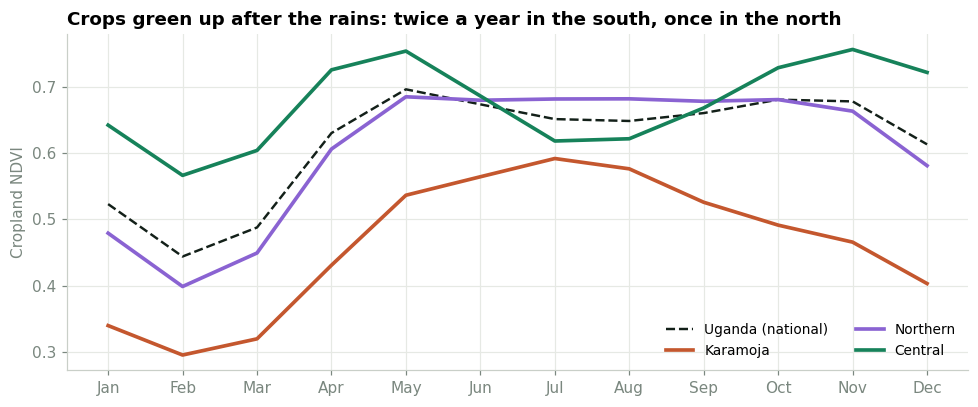

month,1,2,3,4,5,6,7,8,9,10,11,12
region,,,,,,,,,,,,
Uganda (national),0.52,0.44,0.49,0.63,0.70,0.67,0.65,0.65,0.66,0.68,0.68,0.61
Karamoja,0.34,0.30,0.32,0.43,0.54,0.56,0.59,0.58,0.53,0.49,0.47,0.40
Northern,0.48,0.40,0.45,0.61,0.68,0.68,0.68,0.68,0.68,0.68,0.66,0.58
Eastern,0.51,0.44,0.47,0.59,0.67,0.65,0.62,0.61,0.61,0.64,0.64,0.58
Central,0.64,0.57,0.60,0.73,0.75,0.69,0.62,0.62,0.67,0.73,0.76,0.72
Western,0.62,0.54,0.59,0.72,0.75,0.68,0.62,0.62,0.67,0.73,0.76,0.71
Lake Victoria basin,0.65,0.59,0.62,0.72,0.73,0.64,0.55,0.55,0.61,0.70,0.74,0.72


In [3]:
crop = terra[terra['cover'] == 'cropland'].pivot_table(index=['year', 'month'], columns='region', values='ndvi')
clim = crop.groupby(level=1).mean()[REGIONS]
fig, ax = plt.subplots(figsize=(9, 3.8))
colors = {'Karamoja': DRY, 'Northern': '#8a63d2', 'Central': ACCENT, 'Uganda (national)': INK}
for r in ['Uganda (national)', 'Karamoja', 'Northern', 'Central']:
    ax.plot(range(12), clim[r].values, lw=2.4 if r != 'Uganda (national)' else 1.6, color=colors[r],
            ls='-' if r != 'Uganda (national)' else '--', label=r)
ax.set_xticks(range(12)); ax.set_xticklabels(MON)
ax.set_ylabel('Cropland NDVI'); ax.set_title('Crops green up after the rains: twice a year in the south, once in the north')
ax.legend(ncol=2, fontsize=9); plt.tight_layout(); plt.show()
clim.T.round(2)

**Finding:** cropland greenness follows the rain calendar. Central and the Lake Victoria basin green up twice a year, peaking around May and November. Karamoja greens up once, from April to a peak in July–August, and is brown by February. The Northern region stays green from May through October.

---
## 2. How greenness responds to rain

In [4]:
rain = P.load_rain().pivot_table(index=['year', 'month'], columns='region', values='rainfall_mm')
rz, gz = monthly_anomaly(rain), monthly_anomaly(crop)
rows = []
for r in REGIONS:
    row = {'region': r}
    for k in [1, 2, 3, 4]:
        j = pd.concat([gz[r], rz[r].rolling(k).mean()], axis=1).dropna()
        row[f'rain over last {k} mo'] = j.corr().iloc[0, 1]
    rows.append(row)
lag = pd.DataFrame(rows).set_index('region')
lag.round(2)

,rain over last 1 mo,rain over last 2 mo,rain over last 3 mo,rain over last 4 mo
region,,,,
Uganda (national),0.51,0.67,0.68,0.63
Karamoja,0.48,0.66,0.69,0.68
Northern,0.48,0.65,0.65,0.61
Eastern,0.49,0.66,0.69,0.65
Central,0.33,0.44,0.45,0.37
Western,0.41,0.54,0.53,0.48
Lake Victoria basin,0.40,0.53,0.54,0.47


In [5]:
windows = {'Mar–May rain → May–Jul greenness': ((3, 4, 5), (5, 6, 7)),
           'Oct–Dec rain → Nov–Jan greenness': ((10, 11, 12), (11, 12, 1))}
rows = []
for label, (rm, gm) in windows.items():
    rs, gs = seasonal_rain_z(list(rm)), season_greenness(months=gm)
    for r in REGIONS:
        x = rs.xs(r).reindex(gs.index); y = gs[r]
        ok = x.notna() & y.notna()
        c, p = stats.pearsonr(x[ok], y[ok])
        rows.append({'season': label, 'region': r, 'r': c, 'p': p, 'years': int(ok.sum())})
seas = pd.DataFrame(rows).pivot(index='region', columns='season', values=['r', 'p']).reindex(REGIONS)
seas.round(3)

r                                                                 p                                 
season              Mar–May rain → May–Jul greenness Oct–Dec rain → Nov–Jan greenness Mar–May rain → May–Jul greenness Oct–Dec rain → Nov–Jan greenness
region                                                                                                                                                 
Uganda (national)                              0.265                            0.867                            0.200                            0.000
Karamoja                                       0.576                            0.807                            0.003                            0.000
Northern                                       0.265                            0.880                            0.200                            0.000
Eastern                                        0.346                            0.847                            0.090                            0.000
Central                                        0.079                            0.563                            0.707                            0.003
Western                                        0.313                            0.450                            0.128                            0.024
Lake Victoria basin                           -0.001                            0.579                            0.996                            0.002

**Finding:** greenness tracks the previous **two to three months** of rain, with correlations of about 0.65–0.69 in the north, east and Karamoja, and a weaker 0.45–0.55 in Central and Western, where perennial crops and cloud blur the signal.

The two seasons behave very differently:
- **Second season:** October–December rain explains November–January greenness very closely (r = 0.84–0.88 nationally and in the north and east). When the short rains end early, crops and grass dry out fast.
- **First season:** March–May rain barely moves May–July greenness (r ≈ 0.0–0.35), except in Karamoja (r = 0.58). At the height of the long rains, vegetation in wetter regions is near its greenest whatever the exact rainfall, so the index saturates. Greenness is therefore a much better drought indicator for the second season and for dry Karamoja than for the long rains elsewhere.

---
## 3. Does greenness see the droughts?

In [6]:
gA = season_greenness(months=(5, 6, 7))
gB = season_greenness(months=(11, 12, 1))
worst = pd.DataFrame({
    'first season (May–Jul)': gA['Uganda (national)'].sort_values().head(6).round(2).reset_index().apply(lambda r: f"{int(r['index'])}: {r['Uganda (national)']:+.2f}", axis=1).values,
    'second season (Nov–Jan)': gB['Uganda (national)'].sort_values().head(6).round(2).reset_index().apply(lambda r: f"{int(r['index'])}: {r['Uganda (national)']:+.2f}", axis=1).values,
})
worst.index = range(1, 7)
worst

,first season (May–Jul),second season (Nov–Jan)
1,2022: -2.24,2005: -2.04
2,2021: -1.76,2016: -1.94
3,2009: -1.34,2017: -1.29
4,2017: -1.18,2021: -1.17
5,2013: -1.03,2008: -1.16
6,2023: -0.77,2007: -0.88


**Finding:** the worst seasons by national cropland greenness line up with Uganda's recorded droughts: the failed **2005** short rains, the **2016–17** drought (second season 2016 and both 2017 seasons), the **2008–09** drought, and **2021–22**. The worst first season in the 26-year record is **2022**, and the second-worst is **2021**.

---
## 4. A puzzle: 2016–2022

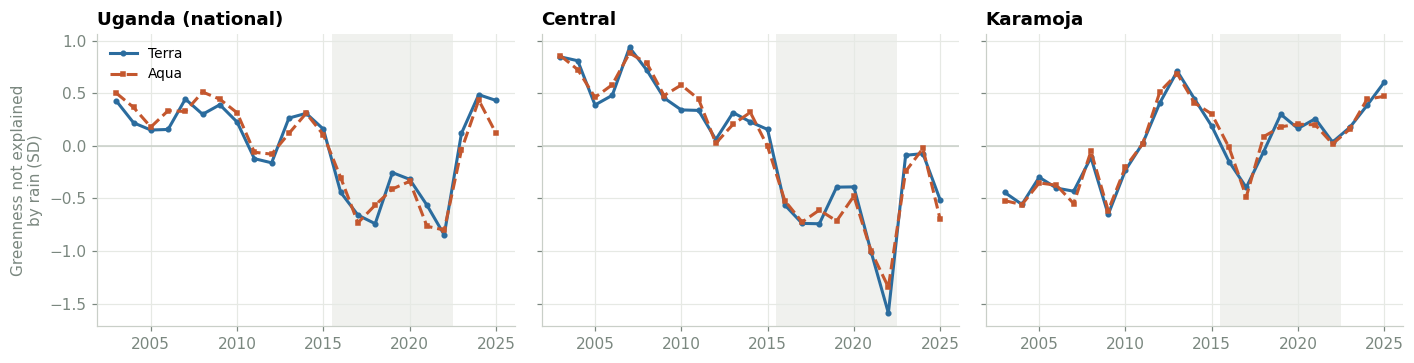

Uganda (national)       Central       Karamoja      
                 Terra  Aqua   Terra  Aqua    Terra  Aqua
year                                                     
2014              0.31  0.31    0.23  0.32     0.45  0.41
2015              0.16  0.11    0.16 -0.00     0.19  0.30
2016             -0.44 -0.30   -0.56 -0.52    -0.15 -0.01
2017             -0.66 -0.73   -0.74 -0.72    -0.39 -0.48
2018             -0.74 -0.56   -0.74 -0.61    -0.06  0.09
2019             -0.25 -0.41   -0.39 -0.71     0.30  0.18
2020             -0.32 -0.34   -0.39 -0.48     0.17  0.21
2021             -0.56 -0.76   -1.01 -1.00     0.26  0.20
2022             -0.85 -0.80   -1.59 -1.34     0.04  0.02
2023              0.12 -0.04   -0.09 -0.24     0.18  0.16
2024              0.49  0.44   -0.07 -0.02     0.39  0.44
2025              0.43  0.12   -0.51 -0.70     0.61  0.47

In [7]:
def residual_by_year(veg, region, start=2003):
    # Greenness anomaly left unexplained by the previous three months' rain, averaged by year
    w = veg[(veg['cover'] == 'cropland') & (veg['region'] == region) & (veg['year'] >= start)]
    w = w.set_index(['year', 'month'])['ndvi']
    j = pd.concat([monthly_anomaly(w.to_frame())['ndvi'], rz[region].rolling(3).mean()], axis=1, keys=['g', 'r']).dropna()
    return sm.OLS(j['g'], sm.add_constant(j['r'])).fit().resid.groupby(level=0).mean()

res = pd.DataFrame({(r, s): residual_by_year(v, r) for r in ['Uganda (national)', 'Central', 'Karamoja']
                    for s, v in [('Terra', terra), ('Aqua', aqua)]})
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4), sharey=True)
for ax, r in zip(axes, ['Uganda (national)', 'Central', 'Karamoja']):
    ax.axhline(0, color='#c9cfc8', lw=1); ax.axvspan(2015.5, 2022.5, color=GRID, alpha=.6, lw=0)
    ax.plot(res.index, res[(r, 'Terra')], color=WET, lw=2, marker='o', ms=3, label='Terra')
    ax.plot(res.index, res[(r, 'Aqua')], color=DRY, lw=2, marker='s', ms=3, ls='--', label='Aqua')
    ax.set_title(r)
axes[0].set_ylabel('Greenness not explained\nby rain (SD)'); axes[0].legend(fontsize=9)
plt.tight_layout(); plt.show()
res.loc[2014:].round(2)

**Finding:** from **2016 to 2022**, cropland nationally and in the centre and south was consistently less green than that period's rainfall would predict. The gap is largest in 2021–22 and closes nationally from 2023, though Central dips again in 2025. Karamoja shows no such gap.

**It is not a sensor artefact.** Terra's orbit has drifted since 2020, which can bias its readings, so the same export was run from Aqua, which crosses in the afternoon. Aqua shows the same gap, of almost the same size, including in 2016–2019, before any drift.

**Three explanations remain**, and this data can't fully separate them:
1. **Crops genuinely did worse than monthly rainfall suggests.** Fall armyworm reached Uganda in 2016 and damaged maize widely in 2016–2018, and dry spells *within* months can hurt crops without lowering monthly totals.
2. **The satellite rainfall overstated rain in those years** in the south and centre, for example through changes in the rain gauges that CHIRPS draws on.
3. **Land-use change against a fixed map.** In Central, the gap is not just an episode: it declines steadily from about +0.9 in 2007 to −1.6 in 2022. The cropland map is a 2021 snapshot, so land that was greener bush or forest before being cleared for farming counts as "cropland" throughout and makes earlier years look greener. Central, with fast land conversion around Kampala, is where this would show most.

The 2016–2022 dip appears nationally on top of a much flatter long-run pattern, so explanations 1 and 2 matter there; in Central, explanation 3 likely contributes too. Checking against station rainfall, a second rainfall product, and a year-by-year cropland map would separate them.

---
## 5. Does greenness predict prices?

In [8]:
# Pre-specified windows: the peak-growth months of each season
WINDOWS = {'A': (5, 6, 7), 'B': (11, 12, 1)}
greens = {k: season_greenness(months=m) for k, m in WINDOWS.items()}

def permutation_p(q, x, B=2000):
    q = q.dropna(subset=['price_anom', x, 'world'])
    yearly = q.groupby('year').agg(p=('price_anom', 'mean'), x=(x, 'mean'), w=('world', 'mean'))
    obs = smf.ols('p ~ x + w', yearly).fit().params['x']
    null = [smf.ols('p ~ x + w', yearly.assign(x=rng.permutation(yearly['x'].values))).fit().params['x'] for _ in range(B)]
    return (np.sum(np.abs(null) >= abs(obs)) + 1) / (B + 1)

rows = []
for com in ['Maize (white)', 'Maize flour', 'Sorghum', 'Beans']:
    pan = season_panel(com)
    for s in ['A', 'B']:
        q = pan[pan['season'] == s].copy()
        g = greens[s]
        q['green_national'] = q['year'].map(g['Uganda (national)'])
        q['green_regional'] = [g[r].get(y) if r in g else np.nan for r, y in zip(q['region'], q['year'])]
        r_nat, r_reg = fit(q, 'green_national'), fit(q, 'green_regional')
        both = q.dropna(subset=['green_national', 'rain_national', 'price_anom', 'world'])
        race = smf.ols('price_anom ~ green_national + rain_national + world + C(market)', both).fit(
            cov_type='cluster', cov_kwds={'groups': both['year']})
        rows.append({'commodity': com, 'season': s,
                     'less_green_pct': 100 * (np.exp(-r_nat['coef']) - 1), 'p': r_nat['p'],
                     'permutation_p': permutation_p(q, 'green_national'),
                     'regional_less_green_pct': 100 * (np.exp(-r_reg['coef']) - 1), 'regional_p': r_reg['p'],
                     'both_in_model_green_p': race.pvalues['green_national'], 'both_in_model_rain_p': race.pvalues['rain_national'],
                     'years': r_nat['years']})
green_price = pd.DataFrame(rows)
green_price.round(3)

,commodity,season,less_green_pct,p,permutation_p,regional_less_green_pct,regional_p,both_in_model_green_p,both_in_model_rain_p,years
0,Maize (white),A,8.702,0.063,0.199,8.389,0.052,0.222,0.019,15
1,Maize (white),B,8.007,0.033,0.116,8.535,0.035,0.420,0.982,16
2,Maize flour,A,8.229,0.077,0.139,7.910,0.050,0.150,0.116,16
3,Maize flour,B,6.235,0.087,0.108,6.716,0.064,0.216,0.639,17
4,Sorghum,A,2.069,0.682,0.809,2.016,0.674,0.934,0.095,15
5,Sorghum,B,8.698,0.002,0.062,9.633,0.000,0.333,0.547,16
6,Beans,A,1.434,0.699,0.850,1.926,0.570,0.978,0.099,18
7,Beans,B,-2.887,0.308,0.415,-2.830,0.327,0.670,0.235,18


**Reading the table:** `less_green_pct` is the change in real prices after a season whose crop greenness was one standard deviation **below** normal (May–July for the first season, November–January for the second). The last two p-value columns put greenness and rainfall in the same model, to see which carries the information.

**Finding:** greenness and prices line up as the chain predicts. Less green seasons are followed by higher prices for maize and maize flour after both seasons, and for sorghum after the second season, by about 6–9% per standard deviation, similar to the rainfall effects in notebook 02. The clearest case is **sorghum after the second season** (about 9%, permutation p ≈ 0.06). With only 15–17 years, none of these passes the permutation test at 5%. Beans again show nothing.

**But greenness doesn't beat rainfall.** With both in the model, neither stands out for the second season: they carry the same information (Section 2: r ≈ 0.85). For the first season, rainfall predicts maize prices better, as expected, since greenness saturates during the long rains.

**A lead for future testing:** among windows tried during exploration, April–June **EVI** (an index that saturates less in lush vegetation) predicted first-season maize prices strongly (about 11% per standard deviation, permutation p ≈ 0.03). Four windows were tried, so after allowing for that search the evidence is about p ≈ 0.13: a hypothesis to test on coming seasons, not a finding.

---
## 6. Karamoja and the 2022 crisis

In [9]:
kar = pd.DataFrame({
    'Karamoja cropland, Jun–Sep': season_greenness(months=(6, 7, 8, 9))['Karamoja'],
    'Karamoja pasture, Jun–Sep': season_greenness(cover='pasture', months=(6, 7, 8, 9))['Karamoja'],
    'National cropland, May–Jul': gA['Uganda (national)'],
    'National cropland, Nov–Jan': gB['Uganda (national)'],
    'National rain, Mar–May': seasonal_rain_z([3, 4, 5]).xs('Uganda (national)'),
    'National rain, Oct–Dec': seasonal_rain_z([10, 11, 12]).xs('Uganda (national)'),
}).loc[2018:2025]
kar.round(2)

,"Karamoja cropland, Jun–Sep","Karamoja pasture, Jun–Sep","National cropland, May–Jul","National cropland, Nov–Jan","National rain, Mar–May","National rain, Oct–Dec"
2018,0.10,0.13,0.14,-0.48,3.69,-0.32
2019,1.47,1.58,0.38,1.62,-0.78,2.72
2020,1.10,0.97,-0.26,0.41,1.34,1.38
2021,0.29,0.44,-1.76,-1.17,-0.37,-0.99
2022,0.75,0.75,-2.24,0.27,-0.73,0.10
2023,-0.55,-0.62,-0.77,1.30,0.37,0.72
2024,1.20,1.20,-0.49,0.81,-1.33,0.55
2025,1.34,1.15,0.32,0.39,0.37,0.64


**Finding:** Karamoja's own crops and pasture were **close to normal or better** in 2021 and 2022. The rest of the country was not: national crop greenness was among the lowest on record in the 2021 first season, the 2021 second season and the 2022 first season. Rainfall points the same way, though less strongly (national March–May rain in 2022 was 0.7 standard deviations below normal, and 1.2 below in the Northern region).

This sharpens the story from notebook 02. Karamoja's staple prices nearly doubled by mid-2022 even though its own harvests were not failing. The spike fits a **national shortage after poor 2021 and 2022 seasons, carried into Karamoja through the market**, compounded by the global grain-price shock of 2022. Karamoja's maize prices move closely with the national market (notebook 02), so a deficit region feels national shortfalls even in a reasonable local year. For early warning, that means national crop conditions matter for Karamoja, not only Karamoja's own rains.

---
## Export

In [10]:
from pathlib import Path
out = Path('../data/processed')
lag.round(4).to_csv(out / 'greenness_rain_lag.csv')
seas.round(4).to_csv(out / 'greenness_rain_seasonal.csv')
res.round(4).to_csv(out / 'greenness_unexplained_by_rain.csv')
green_price.round(4).to_csv(out / 'greenness_price_effects.csv', index=False)
pd.DataFrame({'first_season': gA['Uganda (national)'], 'second_season': gB['Uganda (national)']}).round(4).to_csv(out / 'national_greenness_by_season.csv')
kar.round(4).to_csv(out / 'karamoja_greenness_2018_2025.csv')
print('Saved 6 tables to data/processed/')

Saved 6 tables to data/processed/


---
## Summary

- **Greenness follows rain with a lag of two to three months**, very closely for the second season (r ≈ 0.85) and for Karamoja, but weakly for the first season elsewhere, when vegetation is saturated.
- **It detects Uganda's droughts:** 2005, 2008–09, 2016–17 and 2021–22.
- **From 2016 to 2022, crops in the centre and south were less green than rainfall predicts.** Two satellites agree, so it isn't a sensor artefact. Crops may have done worse than rain suggests (fall armyworm, dry spells), the satellite rainfall may have overstated those years, and in Central a fixed 2021 cropland map probably adds a long-run downward drift.
- **Less green seasons are followed by higher maize and sorghum prices**, by about 6–9% per standard deviation (consistent but not individually significant under the permutation test), and greenness adds little beyond rainfall for prediction.
- **Karamoja's 2022 price spike came while its own crops were near normal**, during national shortfalls: a deficit region feels national shortages.

**Next steps**
1. Check the 2016–22 gap against station rainfall or a second rainfall product (ERA5, TAMSAT).
2. Use a cropland map built for smallholder farming to improve the Central and Western series.
3. Test April–June EVI as an early first-season indicator on coming seasons.